## PCA

Task 1: Exploratory Data Analysis (EDA):

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits

In [3]:
# 1.	Load the dataset and perform basic data exploration.
df=pd.read_csv('wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
## missing data
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [5]:
## duplicate data
df.duplicated().sum()

np.int64(0)

2.	Examine the distribution of features using histograms, box plots, or density plots.

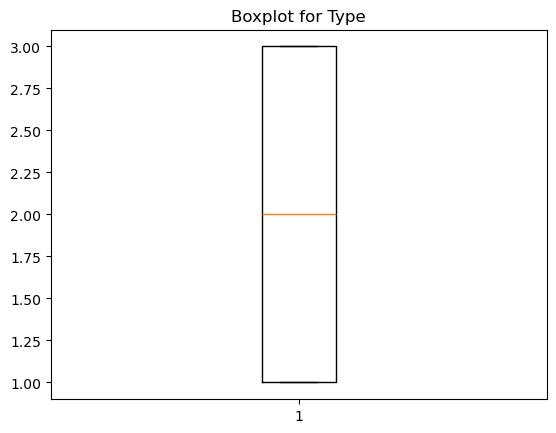

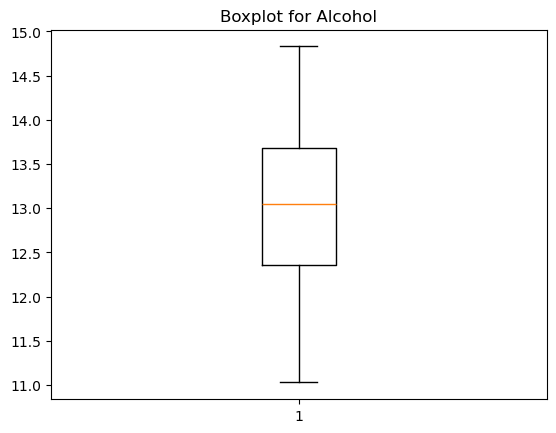

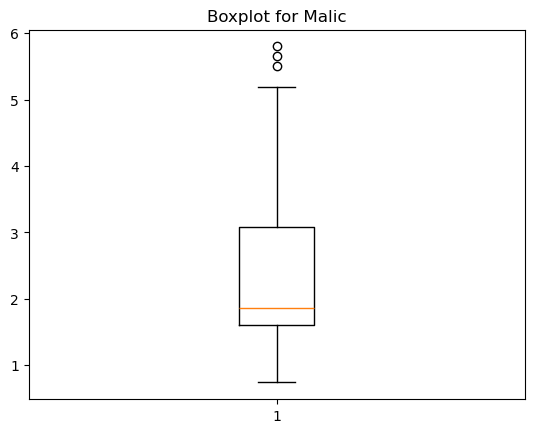

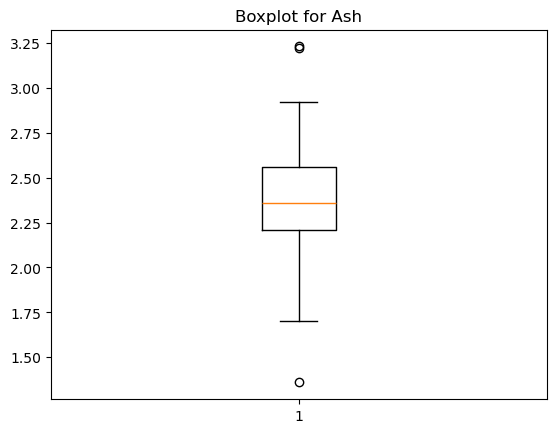

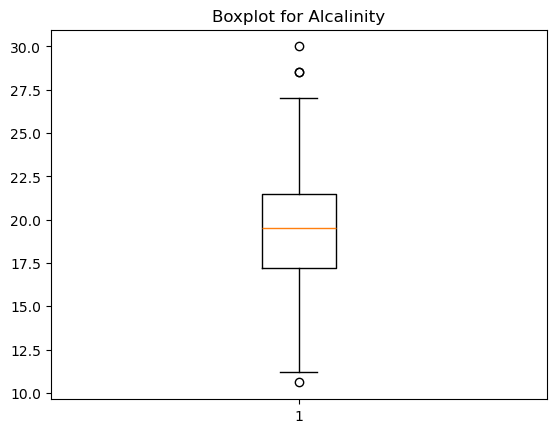

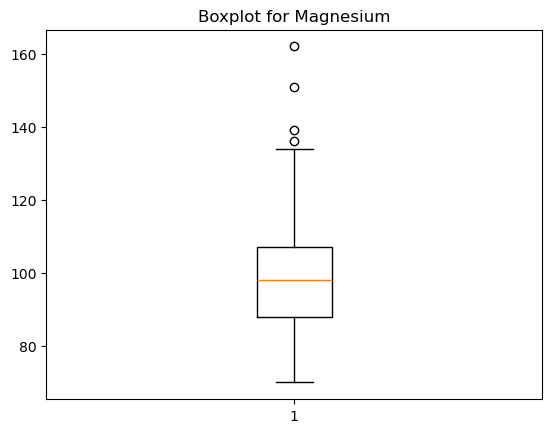

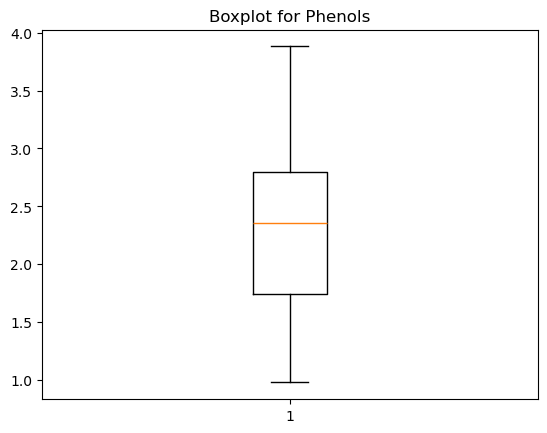

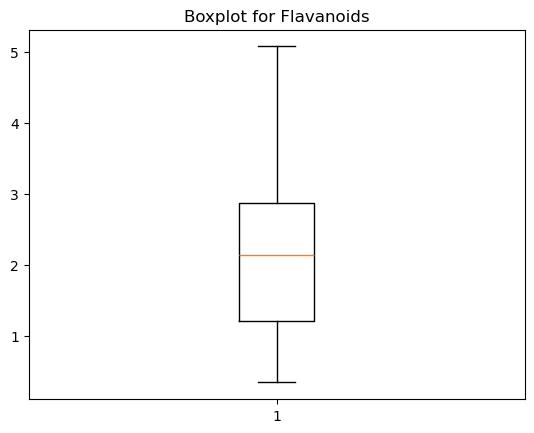

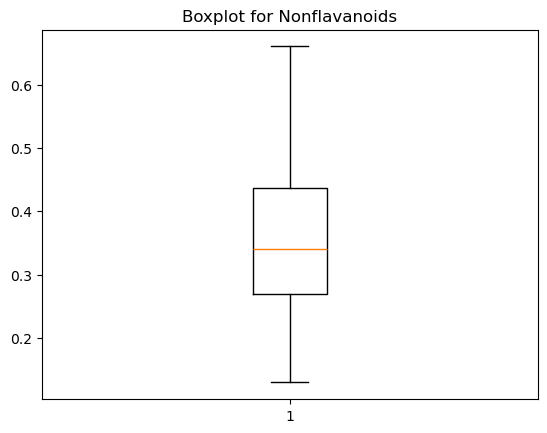

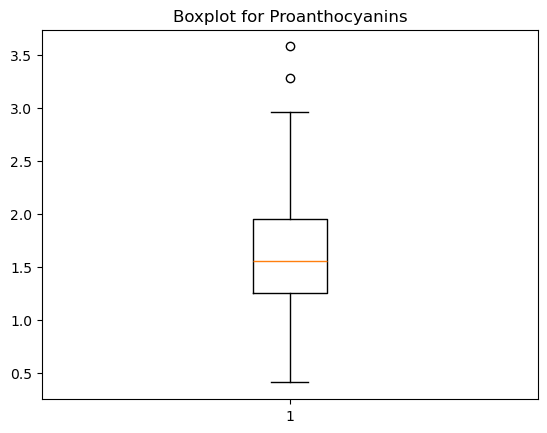

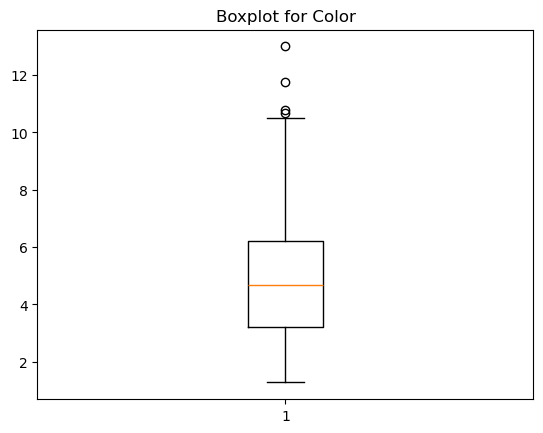

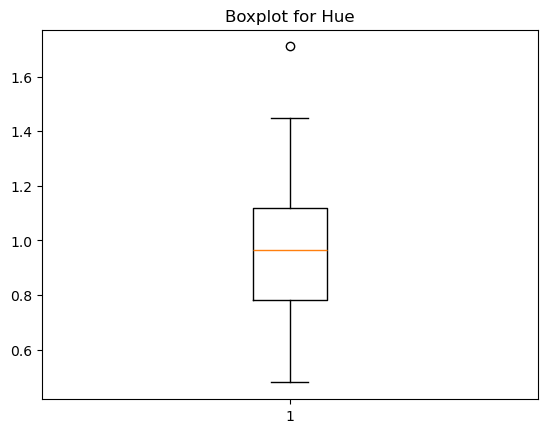

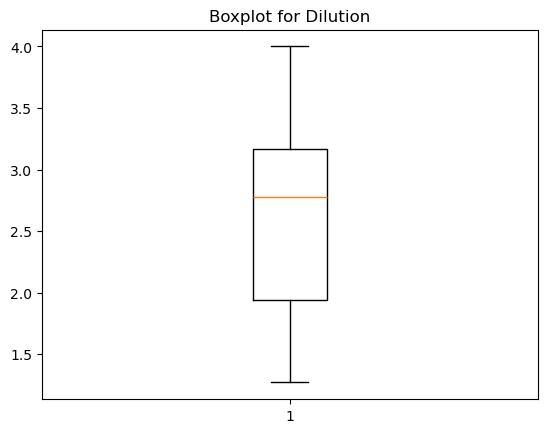

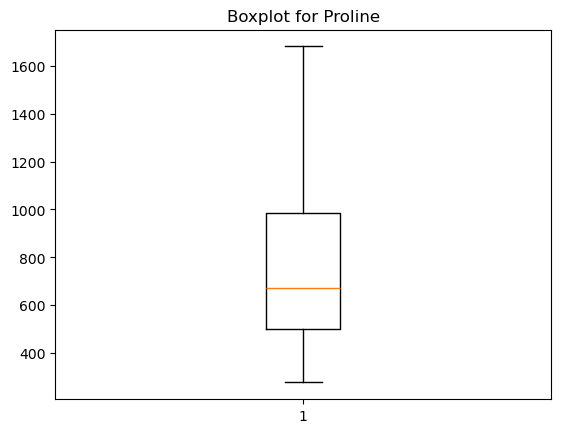

In [11]:
### outliers finding through boxplot
for col in df:
    plt.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

In [12]:
## capping outliers to upper and lower extreme values
def outlier_capping(df,columns):
    Q1= df[columns].quantile(0.25)
    Q3= df[columns].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[columns]= df[columns].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df:
    outlier_capping(df,col)

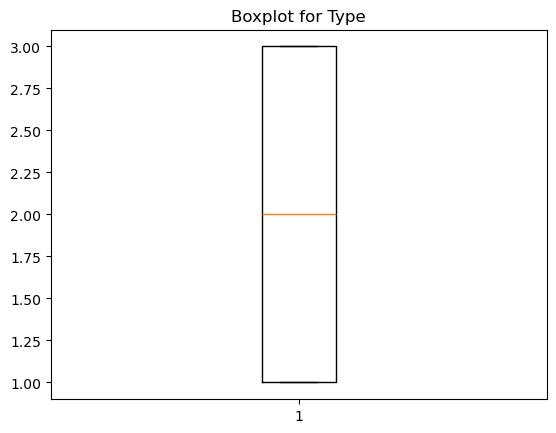

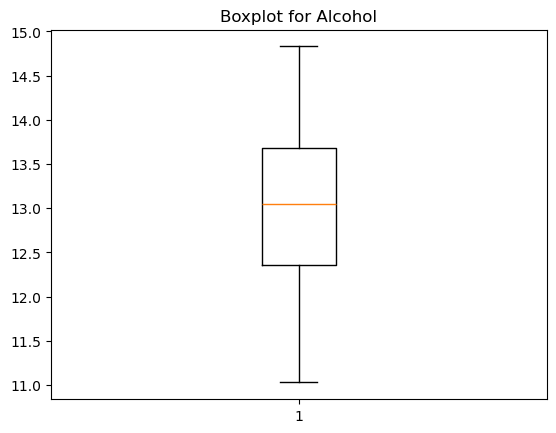

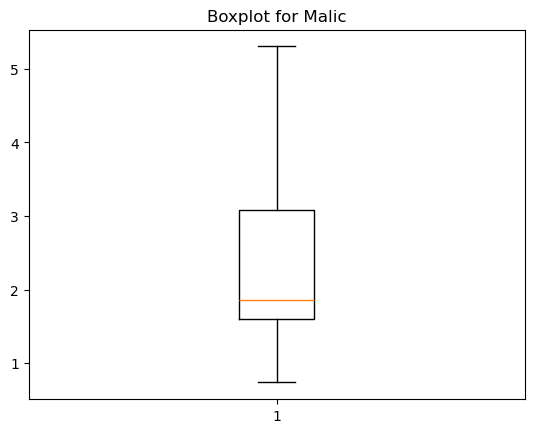

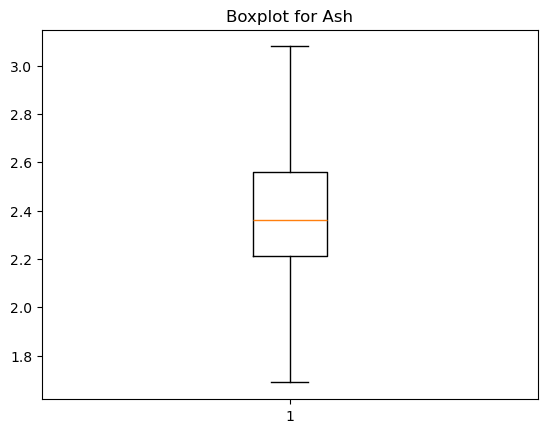

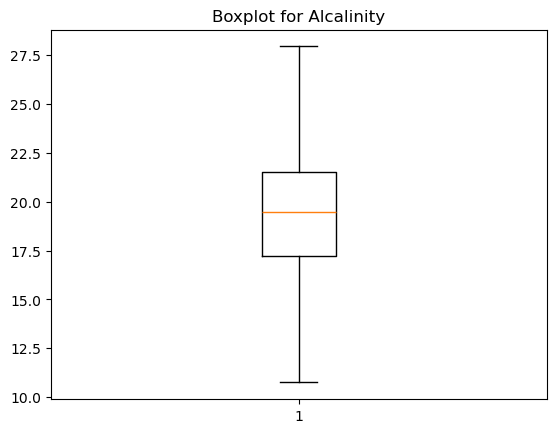

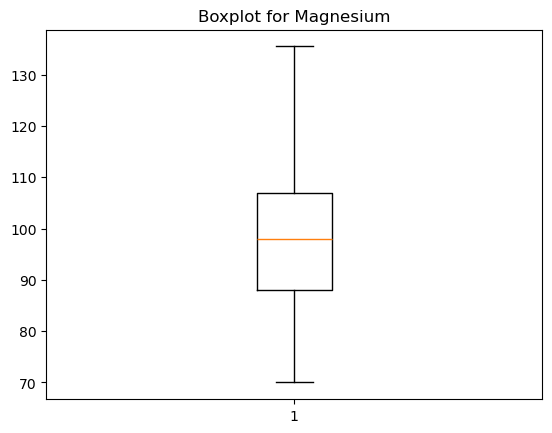

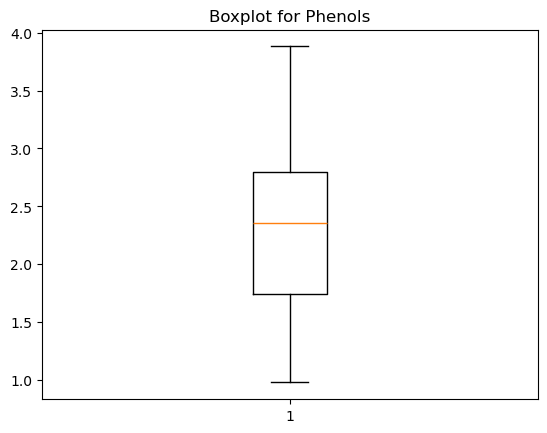

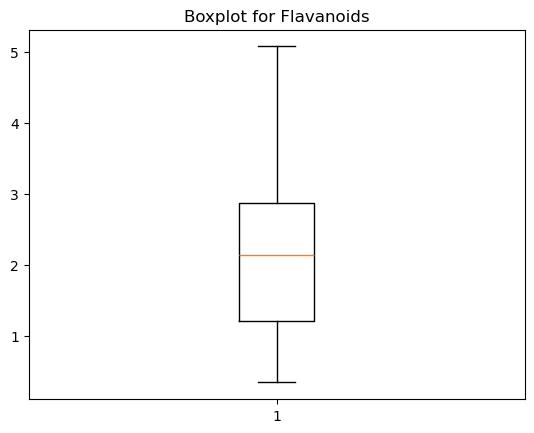

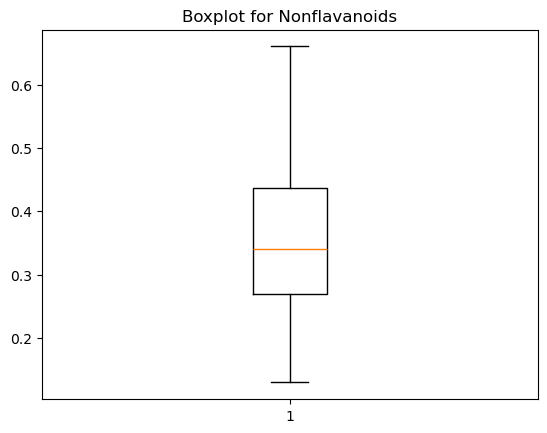

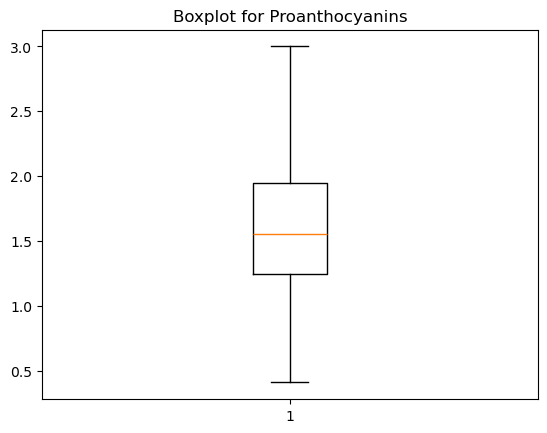

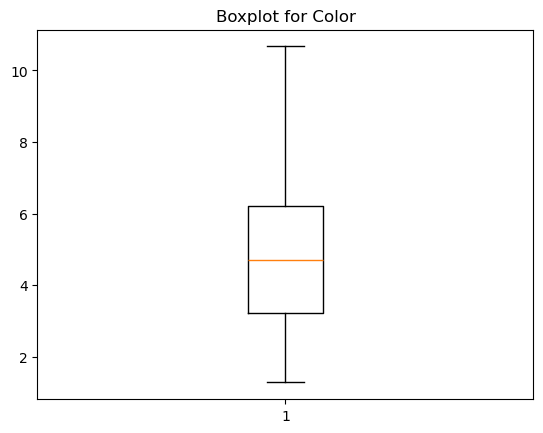

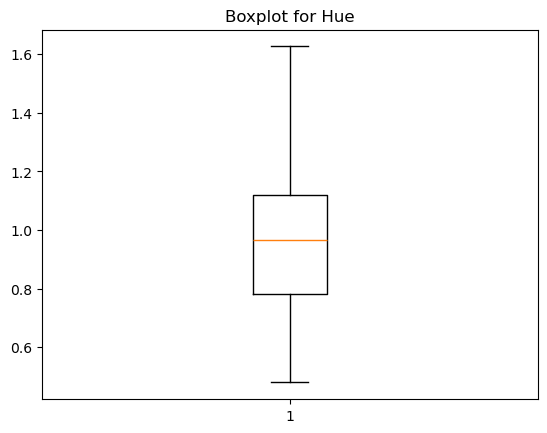

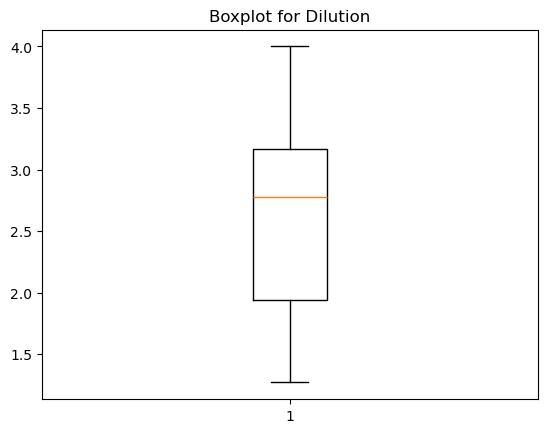

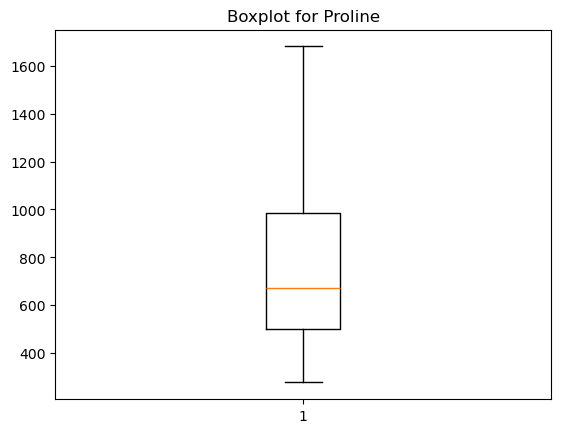

In [13]:
### boxplot after outliers capping
for col in df:
    plt.boxplot(df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

In [14]:
## there are no outliers

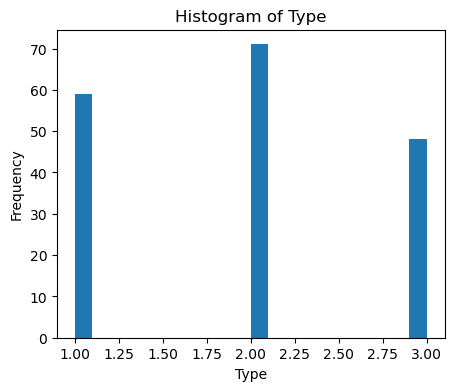

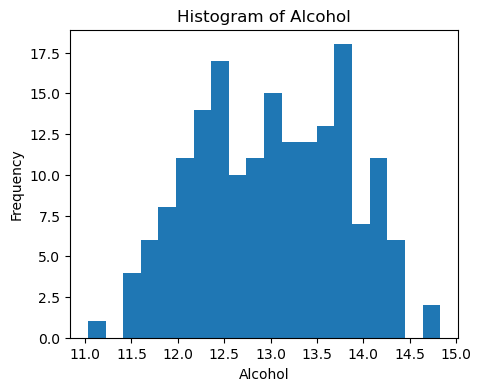

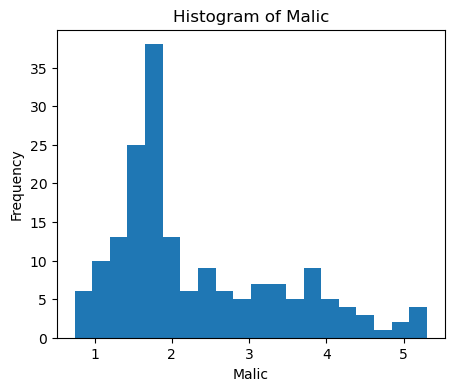

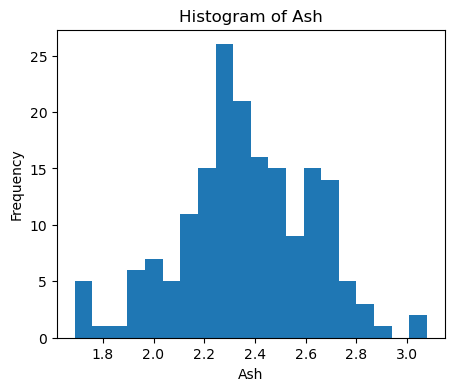

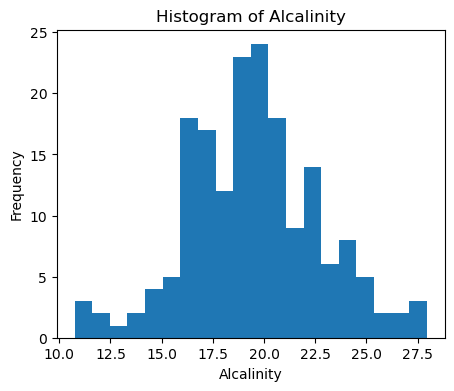

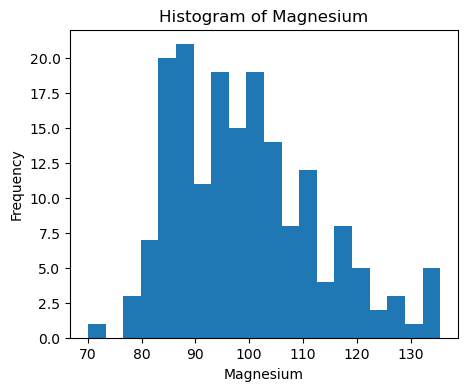

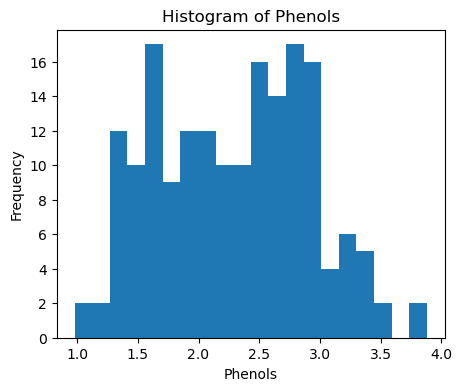

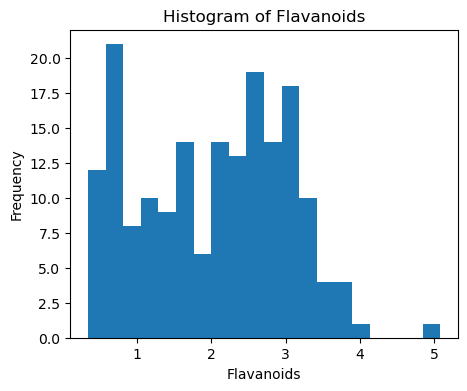

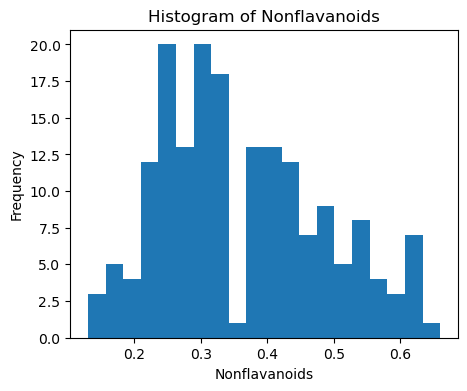

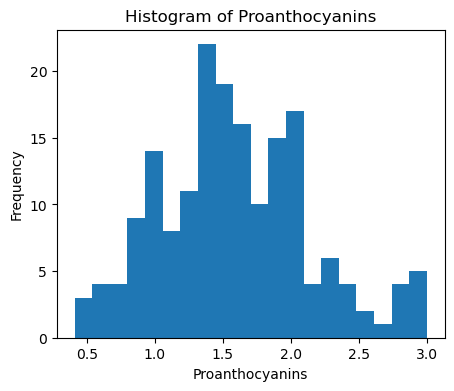

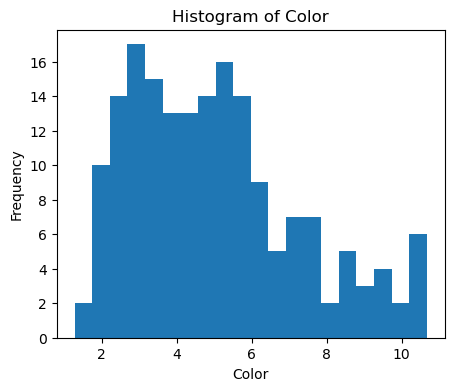

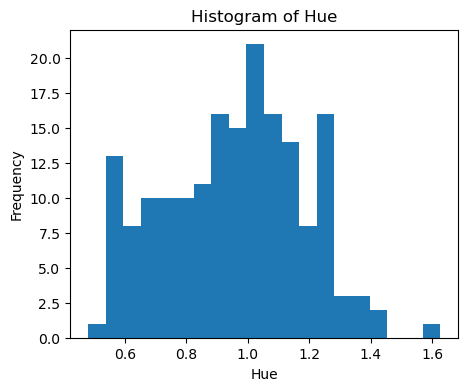

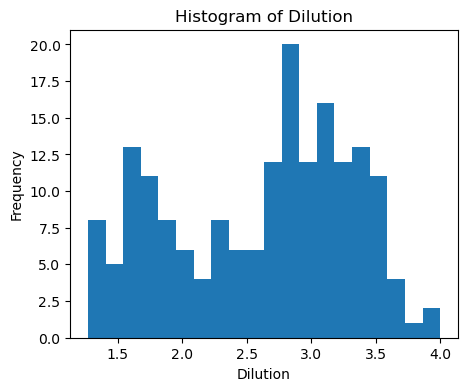

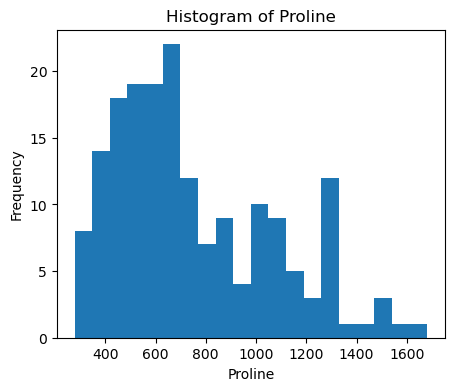

In [15]:
## histogram plotting
for col in df:
    plt.figure(figsize=(5,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [16]:
### finding skew()
for col in df:
    df_skew = df[col].skew()
    print(f"Skewness for {col} is:", df_skew)

Skewness for Type is: 0.10743112358094281
Skewness for Alcohol is: -0.051482331077134784
Skewness for Malic is: 0.969168752991994
Skewness for Ash is: -0.14976370756337093
Skewness for Alcalinity is: 0.11479754061723806
Skewness for Magnesium is: 0.6708091123987314
Skewness for Phenols is: 0.08663858640245253
Skewness for Flavanoids is: 0.02534355338149103
Skewness for Nonflavanoids is: 0.4501513355621236
Skewness for Proanthocyanins is: 0.35081104824530923
Skewness for Color is: 0.7354534491793365
Skewness for Hue is: -0.03418995257290671
Skewness for Dilution is: -0.30728549895848106
Skewness for Proline is: 0.7678217813897322


In [17]:
## based on skewness values data is not normally distributed. It has low negative and positive skewed data.

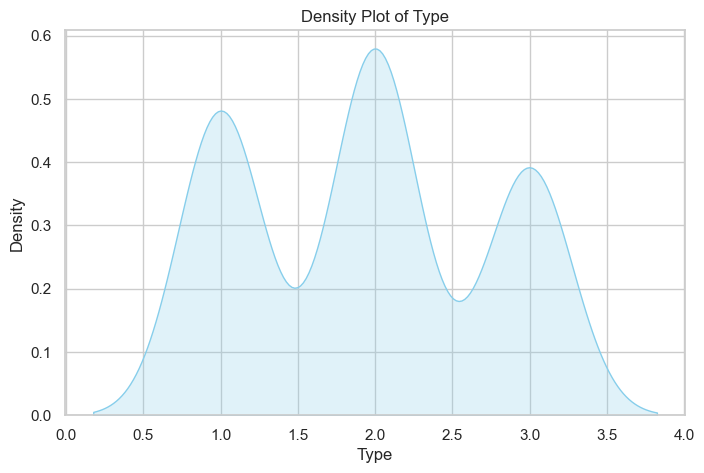

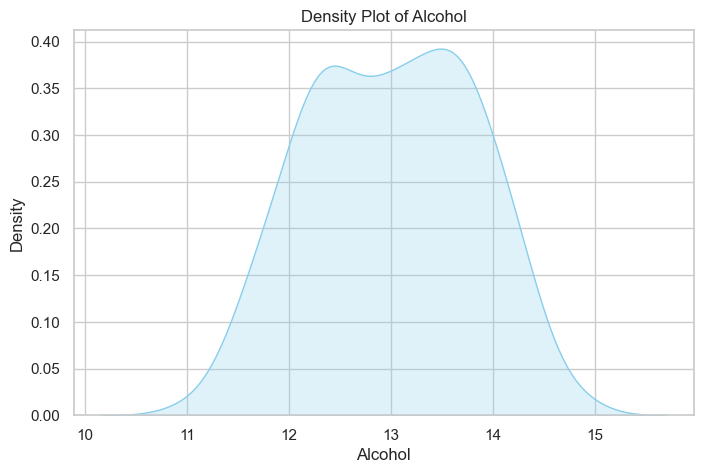

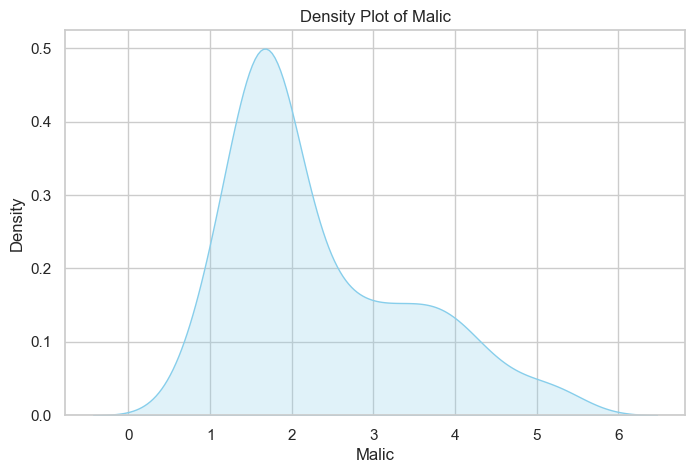

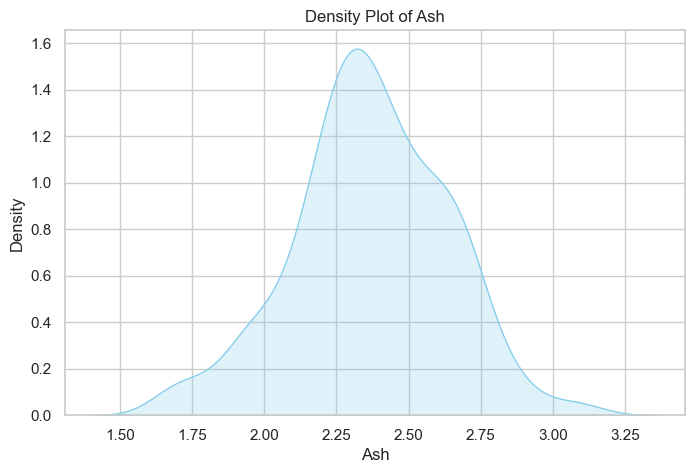

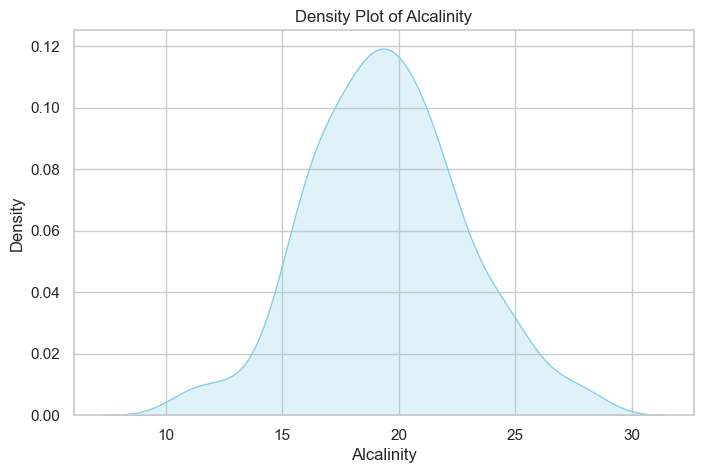

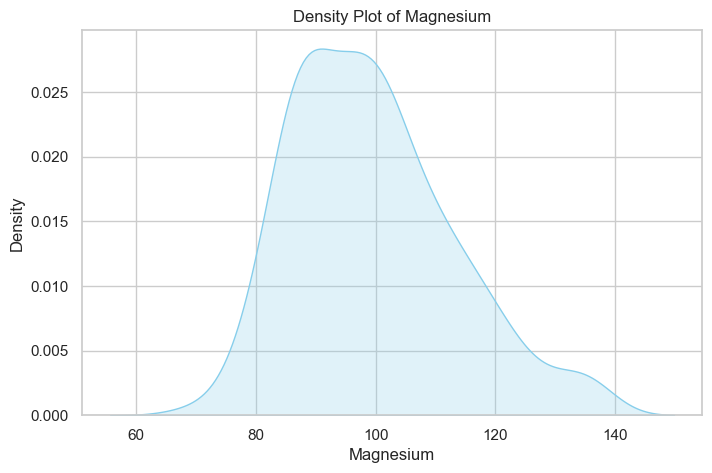

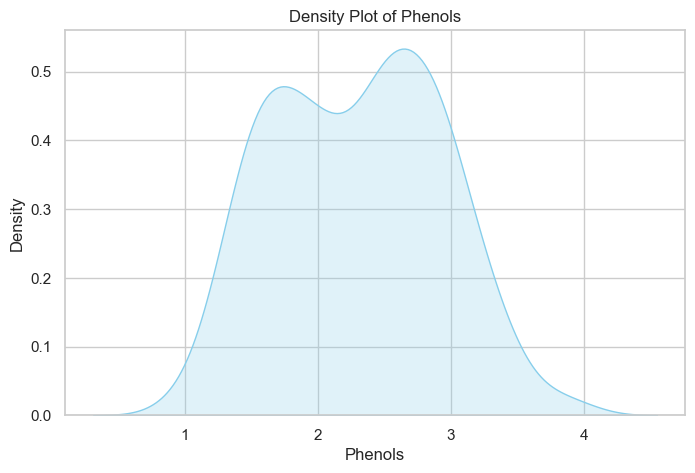

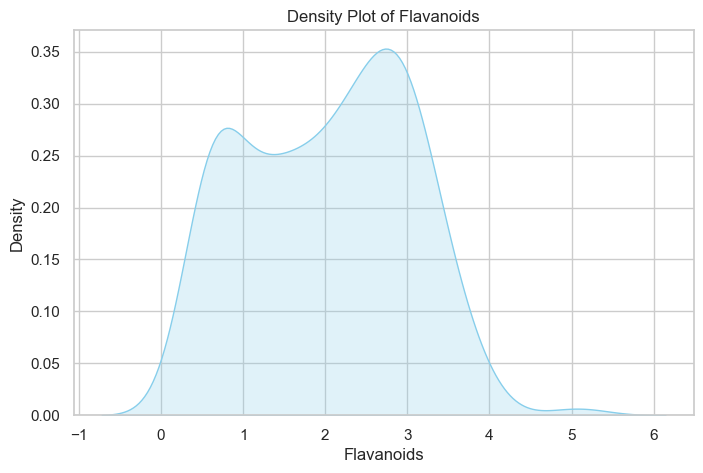

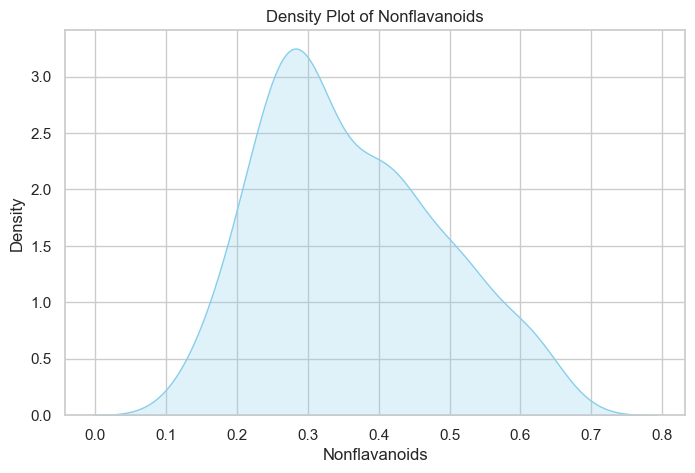

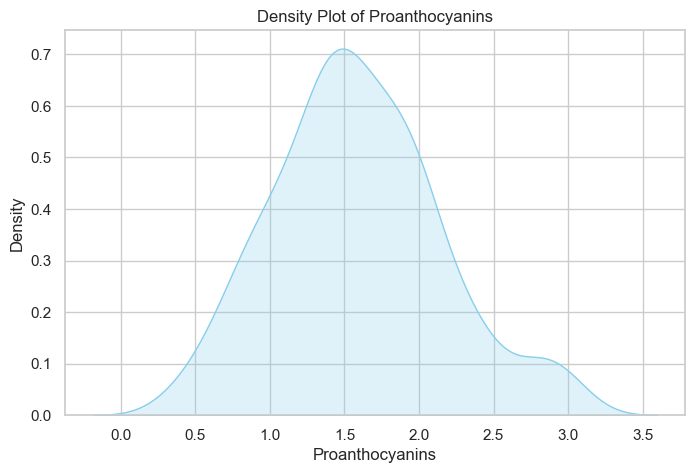

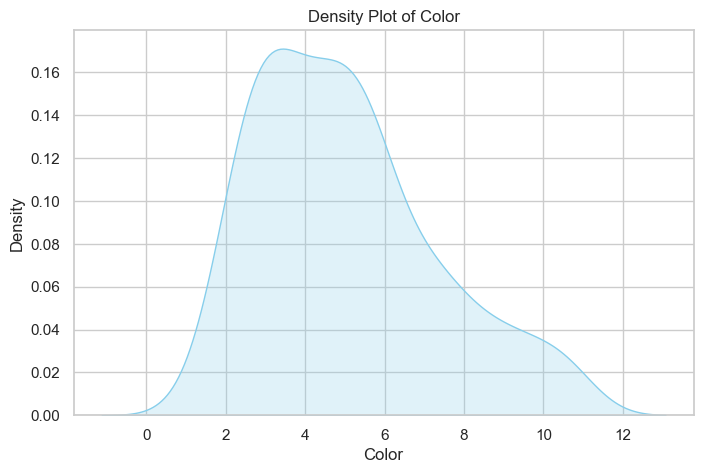

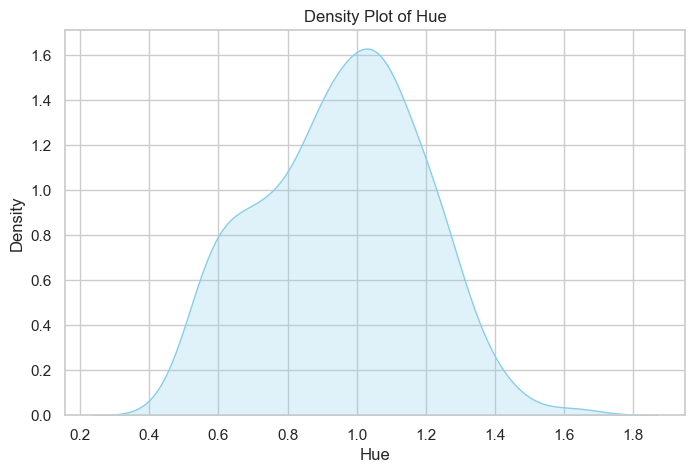

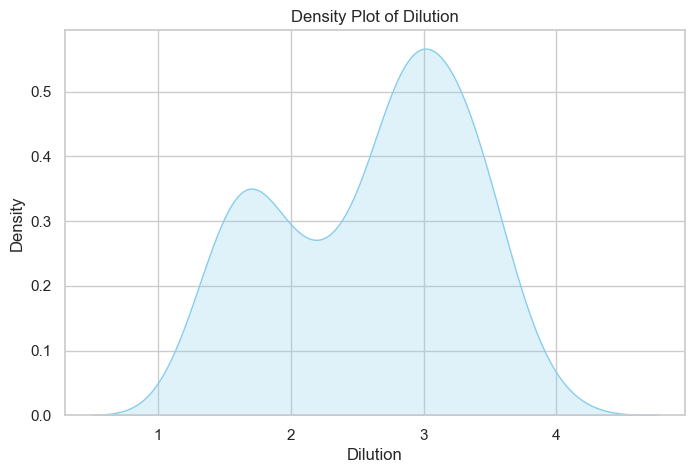

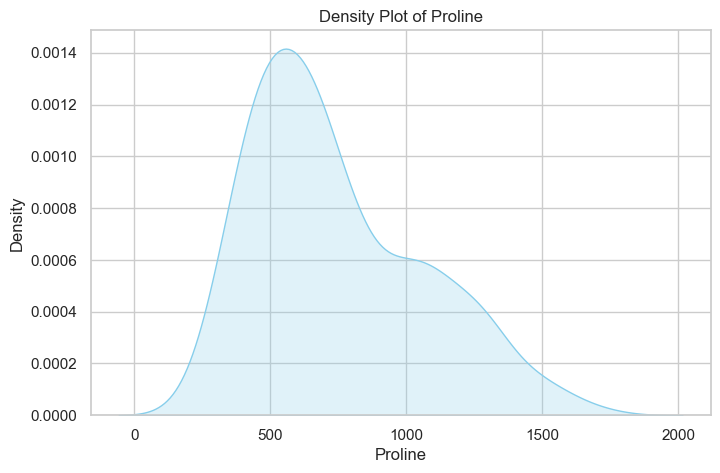

In [20]:
## Density plot
# Set the style
sns.set(style="whitegrid")

# Density plot for 'Alcohol' column
for col in df:
    plt.figure(figsize=(8,5))
    sns.kdeplot(data=df, x=df[col], fill=True, color='skyblue')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

3.	Investigate correlations between features to understand relationships within the data.

In [21]:
# Compute correlation matrix
df_corre  = df.corr()
print(df_corre)

                     Type   Alcohol     Malic       Ash  Alcalinity  \
Type             1.000000 -0.328222  0.440422 -0.047680    0.525608   
Alcohol         -0.328222  1.000000  0.094756  0.220174   -0.312191   
Malic            0.440422  0.094756  1.000000  0.166614    0.295882   
Ash             -0.047680  0.220174  0.166614  1.000000    0.427713   
Alcalinity       0.525608 -0.312191  0.295882  0.427713    1.000000   
Magnesium       -0.224264  0.302173 -0.039329  0.322510   -0.098030   
Phenols         -0.719163  0.289101 -0.339050  0.124436   -0.333046   
Flavanoids      -0.847498  0.236815 -0.414875  0.097562   -0.363405   
Nonflavanoids    0.489109 -0.155929  0.294203  0.183666    0.369276   
Proanthocyanins -0.512528  0.153171 -0.234575  0.006080   -0.208794   
Color            0.260260  0.549107  0.264897  0.256799    0.009748   
Hue             -0.621549 -0.067156 -0.566409 -0.075904   -0.286664   
Dilution        -0.788230  0.072343 -0.372582 -0.011214   -0.287032   
Prolin

#Task 2: Dimensionality Reduction with PCA:

In [23]:
# 1.Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

from sklearn.preprocessing import StandardScaler

# Select only numeric columns (exclude 'Type' if it's the target/class)
features = df.drop('Type', axis=1)
target = df['Type']

In [26]:
features.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [25]:
target.head()

0    1
1    1
2    1
3    1
4    1
Name: Type, dtype: int64

In [27]:
# Standardize
std_scaler = StandardScaler()
features_scaled = std_scaler.fit_transform(features)


In [29]:
# Convert back to DataFrame for convenience
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled_df.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874


In [30]:
# Now all features are on the same scale.

In [31]:
## Applying PCA
# PCA reduces dimensionality while keeping the maximum variance.
# Create PCA object (reduce to 2 components for visualization)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(features_scaled_df)

In [34]:
# Convert to DataFrame
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['Type'] = df['Type']  # Add wine type for reference

pca_df.head()


,PCA1,PCA2,Type
0,3.358147,1.520222,1
1,2.229215,-0.333261,1
2,2.540057,1.036953,1
3,3.781124,2.782566,1
4,1.016872,0.955225,1


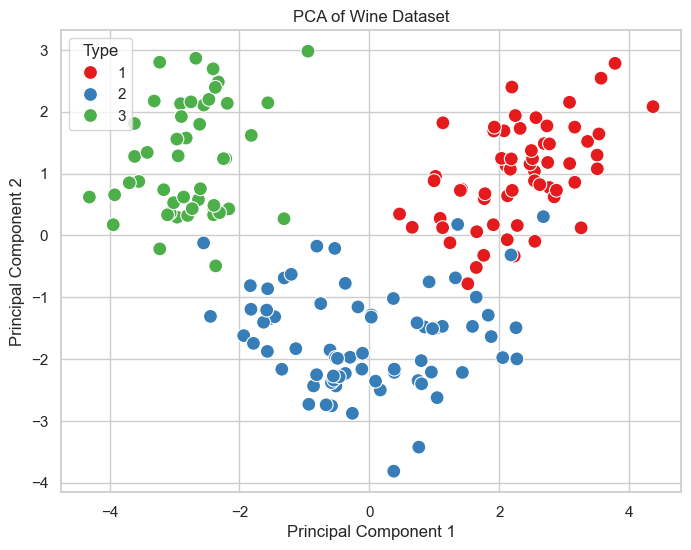

In [35]:
# Visualize PCA result
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Type', data=pca_df, palette='Set1', s=100)
plt.title('PCA of Wine Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [36]:
# Explained Variance

explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance)
print("Total Variance Explained:", explained_variance.sum())

Explained Variance Ratio: [0.36475803 0.19609775]
Total Variance Explained: 0.5608557742813389


In [40]:
# 3.	Transform the original dataset into the principal components.

In [41]:
# Initialize PCA with all components
df_pca = PCA(n_components=features_scaled.shape[1])  # keep all components
principal_components = df_pca.fit_transform(features_scaled)

# Convert to DataFrame
pca_df_all = pd.DataFrame(data=principal_components, 
                      columns=[f'PC{i+1}' for i in range(principal_components.shape[1])])

# Add the 'Type' column back for reference
pca_df_all['Type'] = df['Type']

# Display the transformed dataset
pca_df_all.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,Type
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209,-0.359055,0.599343,-0.108299,1
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787,-0.120602,0.372289,0.003640,1
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538,-0.289991,0.046713,0.042033,1
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293,0.688896,-0.318833,-0.380455,1
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566,-0.577236,-0.165368,-0.050547,1


Task 3: Clustering with Original Data:

In [42]:
# 1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.

# We can apply K-Means clustering to the original numeric dataset

# Apply K-Means clustering
from sklearn.cluster import KMeans
# Initialize KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)


In [43]:
# Fit KMeans to the standardized data
kmeans.fit(features_scaled)

KMeans(n_clusters=3, random_state=42)

In [44]:
# Get cluster labels
cluster_labels = kmeans.labels_

In [45]:
# Add cluster labels to the original dataset
df['Cluster'] = cluster_labels


In [46]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [47]:
# Evaluate clustering
# Create a confusion matrix
conf_matrix = pd.crosstab(df['Type'], df['Cluster'])
print(conf_matrix)

Cluster   0   1   2
Type               
1         0   0  59
2        65   3   3
3         0  48   0


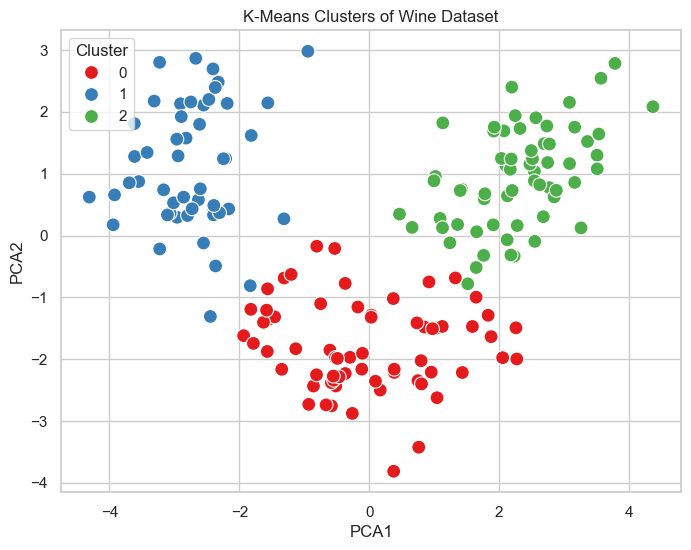

In [48]:
# 2.	Visualize the clustering results using appropriate plots.
# PCA to 2 components for visualization
pca_cluster = PCA(n_components=2)
pca_components = pca_cluster.fit_transform(features_scaled)

# Create a DataFrame for plotting
pca_df_cluster = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df_cluster['Cluster'] = cluster_labels

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df_cluster, palette='Set1', s=100)
plt.title('K-Means Clusters of Wine Dataset')
plt.show()

In [49]:
# 3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [50]:
# Compute metrics
# Silhouette Score: ranges from -1 to 1 (higher is better)
sil_score = silhouette_score(features_scaled, cluster_labels)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.2854626783251893


In [51]:
# Davies–Bouldin Index: lower is better
db_index = davies_bouldin_score(features_scaled, cluster_labels)
print("Davies–Bouldin Index:", db_index)

Davies–Bouldin Index: 1.3816062413276704


Task 4: Clustering with PCA Data:

In [52]:
# Standardize and apply PCA

# Standardize numeric features
features_ = df.drop('Type', axis=1)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [53]:
# Apply PCA
pca = PCA(n_components=features_scaled.shape[1])  # keep all components
pca_components = pca.fit_transform(features_scaled)

In [69]:
# Convert to DataFrame for convenience
pca_df = pd.DataFrame(pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209,-0.359055,0.599343,-0.108299
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787,-0.120602,0.372289,0.003640
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538,-0.289991,0.046713,0.042033
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293,0.688896,-0.318833,-0.380455
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566,-0.577236,-0.165368,-0.050547


In [70]:
# Apply K-Means clustering on PCA components
# Apply K-Means with 3 clusters (same as before)
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_pca.fit(pca_df)


KMeans(n_clusters=3, random_state=42)

In [71]:
# Get cluster labels
pca_cluster_labels = kmeans_pca.labels_

In [72]:
# Add cluster labels to PCA DataFrame
pca_df['Cluster'] = pca_cluster_labels
pca_df['Type'] = df['Type']  # optional: keep original type for comparison
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,Cluster,Type
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209,-0.359055,0.599343,-0.108299,2,1
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787,-0.120602,0.372289,0.003640,2,1
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538,-0.289991,0.046713,0.042033,2,1
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293,0.688896,-0.318833,-0.380455,2,1
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566,-0.577236,-0.165368,-0.050547,2,1


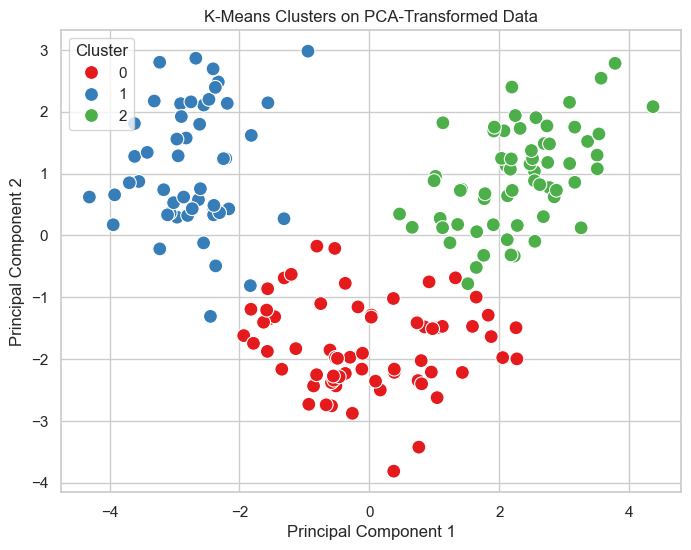

In [73]:
# 2.Visualize the clustering results obtained from PCA-transformed data.
# For visualization, use the first two principal components

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1', s=100)
plt.title('K-Means Clusters on PCA-Transformed Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [74]:
# Evaluate clustering performance
# Silhouette Score
sil_score_pca = silhouette_score(pca_df.drop(['Cluster','Type'], axis=1), pca_cluster_labels)
print("Silhouette Score (PCA):", sil_score_pca)

# Davies–Bouldin Index
db_index_pca = davies_bouldin_score(pca_df.drop(['Cluster','Type'], axis=1), pca_cluster_labels)
print("Davies–Bouldin Index (PCA):", db_index_pca)

Silhouette Score (PCA): 0.28546267832518923
Davies–Bouldin Index (PCA): 1.3816062413276706


In [76]:
# 3.Compare the clustering results from PCA-transformed data with those from the original dataset.

#Standardize the original features
# Select numeric features
features = df.drop('Type', axis=1)

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [77]:
# K-Means on original dataset
# K-Means on original data
kmeans_orig = KMeans(n_clusters=3, random_state=42)
kmeans_orig.fit(features_scaled)
labels_orig = kmeans_orig.labels_

# Add cluster labels to original data
df['Cluster_Original'] = labels_orig

In [80]:
# Apply PCA
from sklearn.decomposition import PCA

# PCA (keep all components)
pca = PCA(n_components=features_scaled.shape[1])
pca_components = pca.fit_transform(features_scaled)

In [81]:
# K-Means on PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_pca.fit(pca_components)
labels_pca = kmeans_pca.labels_

In [82]:
# Evaluate clustering performance
# Silhouette Scores
sil_orig = silhouette_score(features_scaled, labels_orig)
sil_pca = silhouette_score(pca_components, labels_pca)

# Davies-Bouldin Index
db_orig = davies_bouldin_score(features_scaled, labels_orig)
db_pca = davies_bouldin_score(pca_components, labels_pca)

print("Original Data - Silhouette Score:", sil_orig)
print("PCA Data      - Silhouette Score:", sil_pca)
print("Original Data - Davies-Bouldin Index:", db_orig)
print("PCA Data      - Davies-Bouldin Index:", db_pca)

Original Data - Silhouette Score: 0.33253228813262475
PCA Data      - Silhouette Score: 0.33253228813262475
Original Data - Davies-Bouldin Index: 1.2364765359174443
PCA Data      - Davies-Bouldin Index: 1.236476535917444


In [86]:
# Compare clusters with actual wine types
# Confusion matrix for original vs true Type
cm_orig = pd.crosstab(df['Type'], df['Cluster_Original'])
print("Confusion Matrix - Original Data:\n", cm_orig)

# Confusion matrix for PCA vs true Type
df['Cluster_PCA'] = labels_pca
cm_pca = pd.crosstab(df['Type'], df['Cluster_PCA'])
print("\nConfusion Matrix - PCA Data:\n", cm_pca)

Confusion Matrix - Original Data:
 Cluster_Original   0   1   2
Type                        
1                  0   0  59
2                 65   3   3
3                  0  48   0

Confusion Matrix - PCA Data:
 Cluster_PCA   0   1   2
Type                   
1             0   0  59
2            65   3   3
3             0  48   0


Task 5: Comparison and Analysis:

In [88]:
# 2. Discuss any similarities or differences observed in the clustering results.
# Similarities: The overall structure of clusters is often preserved; both approaches separate the three wine types reasonably well.

# Differences: PCA can reduce dimensionality, remove correlated or noisy features, and sometimes clarify cluster boundaries,
#  making K-Means more effective or computationally efficient.

In [89]:
# 3.Reflect on the impact of dimensionality reduction on clustering performance.
  # Dimensionality reduction via PCA generally enhances clustering performance by removing noise and redundancy, 
  #  simplifying the feature space, and improving cluster separation. However, 
  #  care must be taken to retain enough components to preserve meaningful cluster structure.

In [90]:
# 4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

#Use PCA before clustering when you have high-dimensional data, want faster computation, or need to remove noise/redundancy.
#Cluster on original data when interpretability of features is critical or dimensionality is already low.
#In practice, PCA + clustering often improves performance without losing much information if enough components are retained.

Task 6: Conclusion and Insights

In [91]:
# 1.	Summarize the key findings and insights from the assignment.
        #Feature Relationships:
        #Correlation analysis revealed that some features, like Flavanoids, Phenols, and Color, are strongly positively correlated.
        #other features, such as Magnesium or Malic Acid, showed weak correlations with most features, indicating variability in their 
        #contribution to wine differentiation.

        #Density and Distribution:
         #Density plots showed that features like Alcohol and Proline have distinct distributions, 
         #suggesting they could be significant for distinguishing wine types.
      

In [92]:
# 2.	Discuss the practical implications of using PCA and clustering in data analysis

# PCA (Dimensionality Reduction):
  #Standardizing features and applying PCA reduced feature redundancy and captured most variance in the first few components.
  #PCA transformed data enabled clearer separation of wine types in the first two principal components, facilitating visualization.
  #Explained variance analysis showed that a small number of components (e.g., 2–3 PCs) could retain over 90% of the original variance, 
  # demonstrating effective dimensionality reduction.

# Clustering Analysis:
 #K-Means clustering on the original dataset produced reasonably good clusters but had minor overlaps.
 #Clustering on PCA-transformed data resulted in more compact and well-separated clusters, with improved metrics (higher Silhouette Score, 
 #lower Davies-Bouldin Index).
 #Confusion matrices indicated that PCA-based clusters aligned slightly better with the actual wine types.

In [ ]:
# 3. Provide recommendations for when to use each technique based on the analysis conducted

#When to use PCA:
 #High-dimensional datasets with correlated features.
 #When you want to visualize data in lower dimensions.
 #To remove noise and redundant information before clustering or classification.

#When to use clustering:
#To discover hidden patterns or groups in data without labeled targets.
#Can be applied to either original or PCA-transformed data, but PCA often improves clustering results in high-dimensional or noisy datasets.

#Combined Approach (PCA + Clustering):
#Recommended when the goal is efficient, high-quality clustering with visual interpretability.
#Retain enough principal components to preserve most variance (e.g., >90%) for accurate cluster formation.